# California Housing
Utilizar el dataset california housing como ejemplo de problemas de regresión

In [ ]:
#dependencies
import matplotlib.pyplot as plt #librería para hacer gráficos
import numpy as np #librería de matemática
import tensorflow as tf #herramienta para problemas de ML
import tensorflow_datasets as tfds #librería de datasets predeterminados de tensorflow
from tensorflow.keras import layers,models #librería de redes neuronales
import pandas as pd #pandas
from sklearn.cluster import KMeans #modelo de clustering
from sklearn.preprocessing import StandardScaler #tool para guardar normalización
import seaborn as sns #librería para gráficos 

#http://scikit-learn.org/stable/

#librerías de análisis geográfico (para enrichment)
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import nearest_points
coast = gpd.read_file("ne_10m/ne_10m_coastline.shp")

Para empezar importamos el dataset. El mismo consta de 4 listas de elementos:
- x_train: listado de observaciones para entrenar
- x_test: listado de observacioness para testear el modelo (una vez entrenado)
- y_train: listado de valor promedio del inmueble para la observación correspondiente (para entrenar)
- y_test: listado de valor promedio del inmueble para testear el modelo.

El objetivo de este ejercicio va a ser obtener un modelo de machine learning que nos permita predecir los precios de los inmuebles en base a distintos parámetros

In [ ]:
#1. Importar el dataset, con la información para entrenar.
# el dataset tiene 2 arrays (x,y) que dividimos en test - train
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.california_housing.load_data(
    version='large',
    path='california_housing.npz',
    test_split=0.2, #alocamos un 30% del dataset para testear el modelo una vez entrenado
    seed=113
)

El dataset tiene los siguientes parámetros (features) en base a un censo realizado en California -agrupados por manzana: cada observación es una manzana-:
- Latitud
- Longitud
- Edad promedio de los inmuebes (años)
- Cantidad de ambientes (el total de cada manzana)
- Cantidad de habitaciones
- Población viviendo en esa manzana
- Cantidad de hogares
- Mediana de ingresos (/10,000 USD)

In [ ]:
#inicializamos la información dentro de un DataFrame que es un objeto tabular.
headers = ["lon","lat","house_age","rooms","bedrooms","population","households","med_income"] #los encabezados de cada parámetro
df_train = pd.DataFrame(x_train, columns= headers)
df_train['price'] = y_train # el precio del inmueble es la variable a determinar (el eje y)

df_test = pd.DataFrame(x_test,columns = headers)
df_test['price'] = y_test
df_train

,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price
0,-118.269997,34.090000,52.0,2327.0,555.0,1048.0,491.0,3.7847,252300.0
1,-118.360001,33.959999,21.0,1802.0,556.0,1286.0,557.0,2.7284,146900.0
2,-122.389999,37.759998,52.0,1877.0,427.0,712.0,398.0,3.9722,290900.0
3,-117.949997,33.919998,11.0,3127.0,706.0,1594.0,694.0,4.3426,141300.0
4,-122.519997,37.919998,24.0,421.0,64.0,163.0,75.0,14.5833,500001.0
...,...,...,...,...,...,...,...,...,...
16507,-122.029999,37.349998,19.0,3811.0,1227.0,1930.0,1153.0,3.5154,311400.0
16508,-118.440002,34.189999,19.0,3487.0,959.0,2278.0,835.0,2.6709,215500.0
16509,-122.339996,37.570000,52.0,2547.0,373.0,876.0,359.0,8.2598,500001.0
16510,-122.180000,37.889999,18.0,4845.0,735.0,1634.0,734.0,8.1489,499000.0


In [21]:
df_train.describe() # hacemos un análisis rápido de los datos incluídos en el dataset.

,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.00000
mean,-119.562256,35.625362,28.654131,2644.717041,539.574280,1433.272339,501.458344,3.870193,206796.43750
std,2.001168,2.129764,12.597469,2210.147705,426.147156,1156.362427,387.578613,1.897700,115419.15625
min,-124.349998,32.549999,1.000000,2.000000,1.000000,6.000000,1.000000,0.499900,14999.00000
25%,-121.790001,33.930000,18.000000,1451.000000,295.000000,789.000000,279.000000,2.564300,119100.00000
50%,-118.489998,34.250000,29.000000,2133.500000,436.000000,1172.000000,411.000000,3.535700,179450.00000
75%,-118.000000,37.709999,37.000000,3145.250000,649.000000,1735.000000,607.000000,4.738100,265000.00000
max,-114.309998,41.919998,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.00000


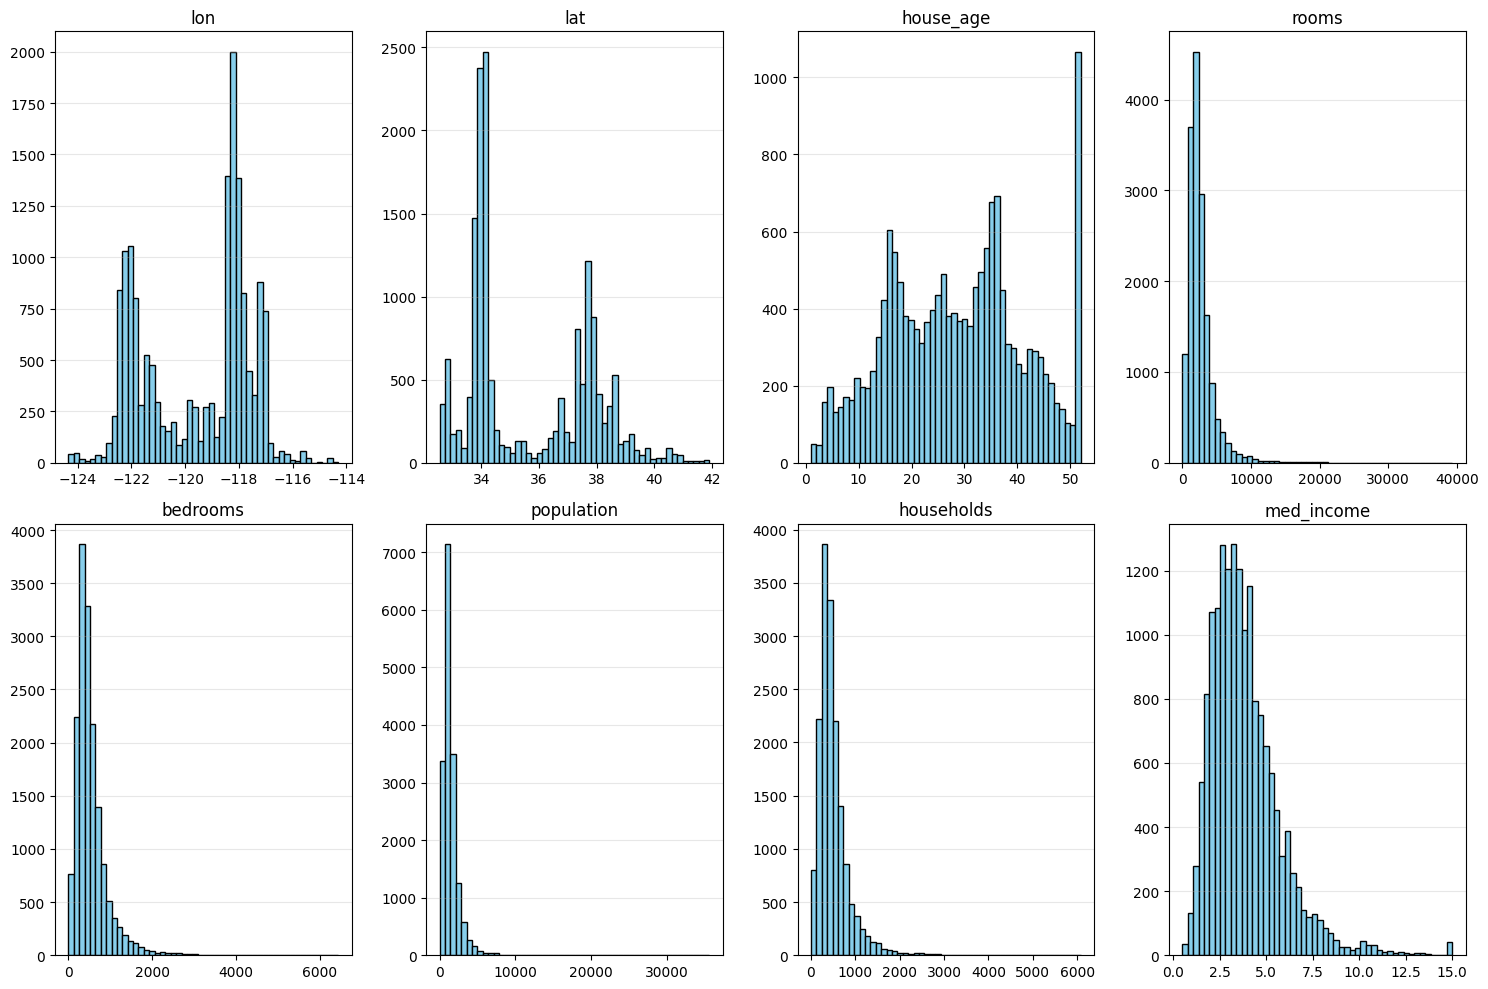

In [ ]:
#vemos rápidamente cómo se distribuye la información de cada feature
plt.figure(figsize=(15, 10))

features = df_train.columns

for i in range(8):
    plt.subplot(2, 4, i + 1) #hacemos un sub-gráfico dentro del elemento gráfico pricipal
    plt.hist(df_train[features[i]], bins=50, color='skyblue', edgecolor='black')
    plt.title(features[i])
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

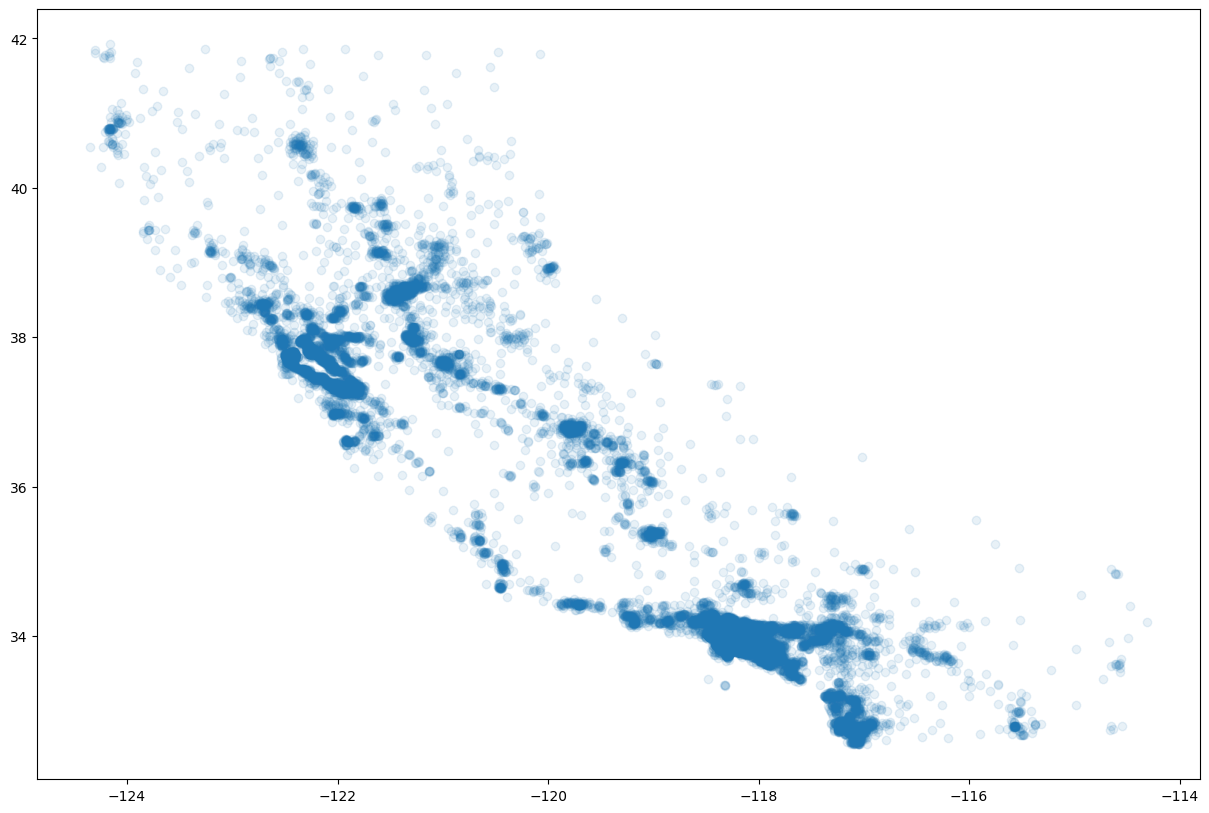

In [ ]:
#visualización de los items latitud y longitud, para verificar que correspondan con la figura general de california
plt.figure(figsize=(15, 10))
plt.scatter(df_train['lon'], df_train['lat'], alpha=0.1)
plt.show()

In [ ]:

clustermodel = KMeans(n_clusters=6, n_init=1, random_state=4)
clustermodel.fit(df_train.iloc[:, [0, 1]])

df_train['cluster'] = clustermodel.predict(df_train.iloc[:, [0, 1]])
df_test['cluster'] = clustermodel.predict(df_test.iloc[:, [0, 1]])
df_test

,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price,cluster
0,-118.360001,34.080002,45.0,2195.0,483.0,1265.0,455.0,3.3864,397900.0,1
1,-120.199997,34.630001,14.0,2647.0,515.0,1487.0,488.0,4.4519,227900.0,5
2,-121.209999,37.810001,8.0,1883.0,298.0,999.0,301.0,5.1930,172100.0,2
3,-122.059998,37.849998,17.0,7475.0,1556.0,2092.0,1449.0,3.6437,186500.0,0
4,-117.400002,33.970001,38.0,1383.0,238.0,649.0,232.0,5.0194,148900.0,1
...,...,...,...,...,...,...,...,...,...,...
4123,-115.730003,32.799999,44.0,472.0,81.0,206.0,57.0,2.2083,93800.0,3
4124,-117.769997,33.759998,19.0,3532.0,402.0,1200.0,426.0,11.0124,500001.0,1
4125,-121.290001,37.970001,52.0,2995.0,555.0,1392.0,503.0,1.7794,98800.0,2
4126,-118.309998,34.040001,52.0,1277.0,285.0,954.0,334.0,2.5833,234600.0,1


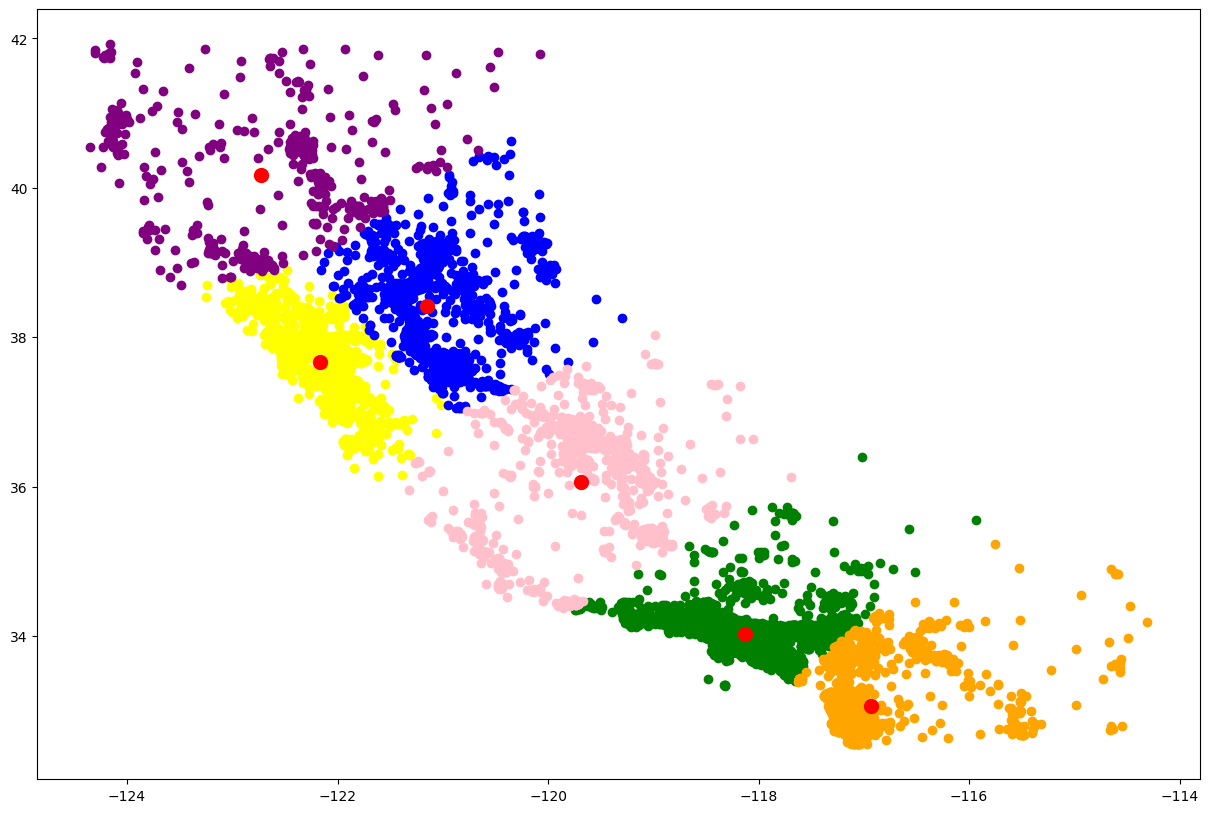

In [25]:
df_cluster1 = df_train[df_train['cluster'] == 0]
df_cluster2 = df_train[df_train['cluster'] == 1]
df_cluster3 = df_train[df_train['cluster'] == 2]
df_cluster4 = df_train[df_train['cluster'] == 3]
df_cluster5 = df_train[df_train['cluster'] == 4]
df_cluster6 = df_train[df_train['cluster'] == 5]

plt.figure(figsize=(15, 10))
# plt.scatter(df_train['lon'], df_train['lat'], alpha=0.1)
plt.scatter(df_cluster1['lon'], df_cluster1['lat'], c='yellow')
plt.scatter(df_cluster2['lon'], df_cluster2['lat'], c='green')
plt.scatter(df_cluster3['lon'], df_cluster3['lat'], c='blue')
plt.scatter(df_cluster4['lon'], df_cluster4['lat'], c='orange')
plt.scatter(df_cluster5['lon'], df_cluster5['lat'], c='purple')
plt.scatter(df_cluster6['lon'], df_cluster6['lat'], c='pink')
plt.scatter(clustermodel.cluster_centers_[:, 0], clustermodel.cluster_centers_[:, 1], s=100, c='red')
plt.show()

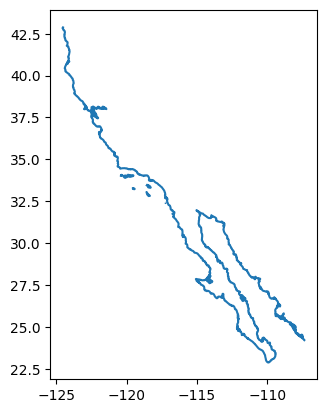

In [26]:
ca_coast = coast.cx[-124:-114 ,32:43]
ca_coast.plot()
plt.show()

In [82]:

def calculate_distance_shore(df,shore):
    gdf_points = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs="EPSG:4326" # Setting the 'starting' CRS as WGS84
    )
    gdf_points = gdf_points.to_crs(epsg=3310)
    coast_gdf = shore.to_crs(epsg=3310)

    ca_coast_union = coast_gdf.geometry.unary_union

    gdf_points['dist_to_coast_km'] = gdf_points.geometry.distance(ca_coast_union) / 1000
    gdf_points = gdf_points.drop('geometry',axis=1)
    return gdf_points
df_train = calculate_distance_shore(df_train,ca_coast)
df_test = calculate_distance_shore(df_test,ca_coast)
df_train.describe()

C:\Users\taniv\AppData\Local\Temp\ipykernel_16468\3986548.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ca_coast_union = coast_gdf.geometry.unary_union
C:\Users\taniv\AppData\Local\Temp\ipykernel_16468\3986548.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ca_coast_union = coast_gdf.geometry.unary_union


,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price,cluster,dist_to_coast_km
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.00000,16512.000000,16512.000000
mean,-119.562256,35.625362,28.654131,2644.717041,539.574280,1433.272339,501.458344,3.870193,206796.43750,1.509145,39.183389
std,2.001168,2.129764,12.597469,2210.147705,426.147156,1156.362427,387.578613,1.897700,115419.15625,1.448960,49.738005
min,-124.349998,32.549999,1.000000,2.000000,1.000000,6.000000,1.000000,0.499900,14999.00000,0.000000,0.001366
25%,-121.790001,33.930000,18.000000,1451.000000,295.000000,789.000000,279.000000,2.564300,119100.00000,1.000000,6.693458
50%,-118.489998,34.250000,29.000000,2133.500000,436.000000,1172.000000,411.000000,3.535700,179450.00000,1.000000,18.854683
75%,-118.000000,37.709999,37.000000,3145.250000,649.000000,1735.000000,607.000000,4.738100,265000.00000,2.000000,49.408656
max,-114.309998,41.919998,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.00000,5.000000,333.781567


In [120]:
#outlier cleanup
avg = df_train.mean()
std = df_train.std()
# rooms_avg
df_train = df_train.loc[df_train['rooms']<= (avg['rooms'] + std['rooms'] * 3 )]
df_train = df_train.loc[df_train['bedrooms']<= (avg['bedrooms'] + std['bedrooms'] * 3 )]
df_train = df_train.loc[df_train['population']<= (avg['population'] + std['population'] * 3 )]
df_train = df_train.loc[df_train['med_income']<= (avg['med_income'] + std['med_income'] * 3 )]

df_train.describe()



,lon,lat,house_age,rooms,bedrooms,population,households,med_income,price,cluster,dist_to_coast_km
count,14329.000000,14329.000000,14329.000000,14329.000000,14329.000000,14329.000000,14329.000000,14329.000000,14329.00000,14329.000000,14329.000000
mean,-119.599770,35.673347,29.855818,2107.601074,434.782745,1161.680786,407.300873,3.668891,198256.65625,1.547003,40.008923
std,2.000446,2.153269,12.280729,1038.549438,209.584595,567.165405,195.071716,1.533994,108800.25000,1.478597,50.948536
min,-124.349998,32.549999,1.000000,2.000000,2.000000,6.000000,2.000000,0.499900,14999.00000,0.000000,0.001366
25%,-121.800003,33.939999,20.000000,1369.000000,284.000000,753.000000,268.000000,2.523400,114400.00000,1.000000,6.591403
50%,-118.559998,34.279999,31.000000,1968.000000,406.000000,1089.000000,383.000000,3.467100,174400.00000,1.000000,18.835356
75%,-118.029999,37.730000,38.000000,2741.000000,565.000000,1520.000000,530.000000,4.591300,253900.00000,2.000000,50.530456
max,-114.489998,41.919998,52.000000,5268.000000,1070.000000,2874.000000,1059.000000,8.488900,500001.00000,5.000000,333.781567


In [131]:
class MLmodel():
    def __init__(self):
        self.model = self.build_model()
        self.scaler = StandardScaler()

        self.label_col_name = 'price'
        self.categorical_cols_name = ['geocluster_0','geocluster_1','geocluster_2','geocluster_3','geocluster_4','geocluster_5']
        self.numerical_cols_name = ['latxlong','avg_rooms','avg_pop_house','beds_to_rooms','dist_to_coast_km','med_income','avg_bedrooms']
        self.x_test = np.array([])
        self.y_test = np.array([])
        self.x_train = np.array([])
        self.y_train = np.array([])
        self.prepped_train = pd.DataFrame()
        
    def build_model(self):
        #1. Model layer definitions
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(units=128,activation='relu'),
            tf.keras.layers.Dense(units=64,activation='relu'),
            tf.keras.layers.Dense(units=32,activation='relu'),
            tf.keras.layers.Dense(units=1,activation=None)
            ])
        #2. Model loss function and optimizer
        model.compile(
            loss=tf.keras.losses.MSE,
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
            metrics = ['mae']
            )
        #3. Return the initialized model
        return model
    def _dataprepfunc(self,sourcem):
        """
        Espacio para customizar los datasets.
        """
        modeldf = pd.DataFrame()
        sourcem = sourcem.dropna()
        modeldf['latxlong'] = sourcem['lat'] * sourcem['lon'] 
        modeldf['avg_rooms'] = sourcem['rooms'] / sourcem['households']
        modeldf['avg_bedrooms'] = sourcem['bedrooms']/ sourcem['households']
        modeldf['avg_pop_house']= sourcem['population']/ sourcem['households']
        modeldf['beds_to_rooms'] = sourcem['bedrooms']/ sourcem['rooms']
        modeldf['dist_to_coast_km'] = sourcem['dist_to_coast_km']
        modeldf['med_income'] = sourcem['med_income']
        modeldf['price'] = sourcem['price']

        clusterq = sourcem['cluster'].nunique() #number of unique values
        cluster_ids = sourcem['cluster'].values #array of values
        one_hot_encoded_matrix = np.eye(clusterq)[cluster_ids] #np.eye(n) creates n-rank identity matrix. [cluster_ids] searches the 'cluster_id'-index inside the identity matrix
        cluster_cols = [f'geocluster_{i}' for i in range(clusterq)] #names of one-hot columns
        cluster_df = pd.DataFrame(one_hot_encoded_matrix, columns=cluster_cols, index=modeldf.index) # clusterdf
        modeldf = pd.concat([modeldf, cluster_df], axis=1) #merge one-hot with original df
        
        return modeldf

    def prepare(self,train,test):
        """
        Función que aplica las transformaciones del dataset y ajusta el scaler en base a la información de test
        Input:
        train = DataFrame con data de test
        test = DataFrame con data de test
        """
        
        train_prep = self._dataprepfunc(train)
        test_prep = self._dataprepfunc(test)
        
        #scaling only on the train numerical columns
        self.scaler.fit(train_prep[self.numerical_cols_name])

        def assemble(df):
            scaled_num = self.scaler.transform(df[self.numerical_cols_name])
            categorical = df[self.categorical_cols_name].values
            return np.hstack([scaled_num, categorical]) # Merges them side-by-side

        self.x_train = assemble(train_prep)
        self.x_test = assemble(test_prep)
        self.y_train = np.log1p(train_prep[self.label_col_name].values)
        self.y_test = np.log1p(test_prep[self.label_col_name].values)
        
        self.prepped_train = train_prep

    def train(self):
        callbacks = []
        return self.model.fit(self.x_train,self.y_train,
            epochs = 50,
            batch_size = 64,
            validation_data=(self.x_test, self.y_test),
            verbose = 1,
            callbacks = callbacks,
            shuffle = True
        )
    def inference(self,X):
        features = self._dataprepfunc(X)
        def assemble(df):
            scaled_num = self.scaler.transform(df[self.numerical_cols_name])
            categorical = df[self.categorical_cols_name].values
            return np.hstack([scaled_num, categorical]) # Merges them side-by-side

        scaled_features = assemble(features)
        log_predictions = self.model.predict(scaled_features)
        return np.expm1(log_predictions)

    def plot_correlation(self, feature_name):
        """
        Plots a scatter plot of a specific feature vs Price.
        Includes a 'lowess' trend line to see the non-linear relationship.
        """
        df = self.prepped_train
        plt.figure(figsize=(10, 6))
        
        # Taking a sample of 2000 points so the plot is readable
        sample_df = df.sample(n=min(2000, len(df)), random_state=42)
        
        sns.regplot(
            data=sample_df, 
            x=feature_name, 
            y='price', 
            scatter_kws={'alpha': 0.3, 's': 10},
            line_kws={'color': 'red'},
            # lowess=True # This shows the actual trend, not just a straight line
        )
        
        plt.title(f'Relationship: {feature_name} vs House Price')
        plt.xlabel(feature_name)
        plt.ylabel('Price ($)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()


- $MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
- $MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

In [132]:
model = MLmodel()
model.prepare(train = df_train,test = df_test)
history = model.train()

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.8411 - mae: 1.1283 - val_loss: 0.2542 - val_mae: 0.3593
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3420 - mae: 0.3539 - val_loss: 0.1257 - val_mae: 0.2514
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1523 - mae: 0.2633 - val_loss: 0.1188 - val_mae: 0.2428
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2236 - mae: 0.2776 - val_loss: 0.1876 - val_mae: 0.2898
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2100 - mae: 0.2842 - val_loss: 0.1284 - val_mae: 0.2497
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1416 - mae: 0.2504 - val_loss: 0.3213 - val_mae: 0.2828
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1083 - mae: 0.2384 - val_loss: 0.1201 - val_mae: 0.2299
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1912 - mae: 0.2703 - val_loss: 0.9511 - val_mae: 0.4863
Epoch 9/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

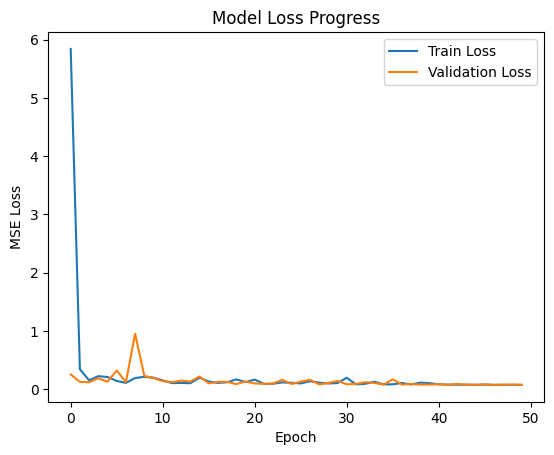

In [133]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [134]:
predictions = model.inference(df_test)
real_mae = np.mean(np.abs(predictions.flatten() - df_test['price'].values))
print(f"Real Error: ${real_mae:,.2f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Real Error: $39,921.18


['latxlong', 'avg_rooms', 'avg_pop_house', 'beds_to_rooms', 'dist_to_coast_km', 'med_income', 'avg_bedrooms']


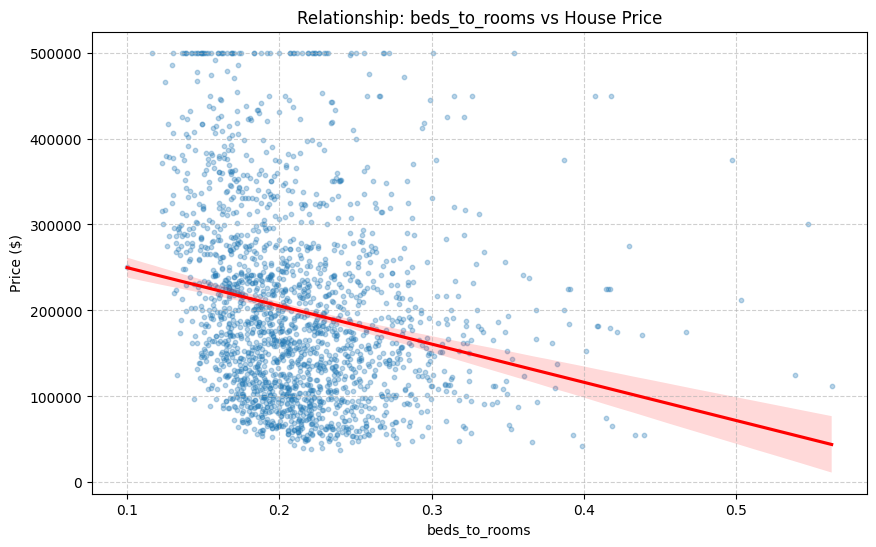

In [136]:
print(model.numerical_cols_name)
model.plot_correlation('beds_to_rooms')
# model.prepped_train